# SUFE VOS Leaderboard Colab

This notebook prepares SUFE leaderboard data, detects prompts, inspects the sample submission format, and writes data-stage artifacts under `outputs/{experiment_id}/`.

In [1]:
# Runtime variables and paths
from __future__ import annotations

import csv
import datetime as _dt
import json
import os
from pathlib import Path
import shutil
import subprocess
import sys
import zipfile

IS_COLAB = "google.colab" in sys.modules
DRIVE_ROOT = Path(os.environ.get("SUFE_DRIVE_ROOT", "/content/drive/MyDrive"))
DEFAULT_PROJECT_ROOT = Path("/content/sufe_vos_leaderboard") if IS_COLAB else Path.cwd()
PROJECT_ROOT = Path(os.environ.get("SUFE_PROJECT_ROOT", str(DEFAULT_PROJECT_ROOT))).expanduser().resolve()

if IS_COLAB:
    try:
        from google.colab import drive

        drive.mount("/content/drive", force_remount=False)
        drive_project = DRIVE_ROOT / "sufe_vos_leaderboard"
        if not PROJECT_ROOT.exists() and drive_project.exists():
            PROJECT_ROOT = drive_project.resolve()
    except Exception as exc:
        print(f"Google Drive mount skipped: {exc}")

PROJECT_MARKER = PROJECT_ROOT / "src" / "data" / "inspect_sufe.py"
if not PROJECT_MARKER.exists():
    raise RuntimeError(
        f"Project root is wrong or incomplete: {PROJECT_ROOT}\n"
        "Expected to find src/data/inspect_sufe.py under PROJECT_ROOT. "
        "Set SUFE_PROJECT_ROOT to your mounted sufe_vos_leaderboard folder before rerunning this cell."
    )

DATA_URL = "https://drive.google.com/file/d/12PLrZwDvpeO3n-IQbAMgA9FOM0xdOqRr/view?usp=sharing"
DEFAULT_DATA_ZIP = DRIVE_ROOT / "sufe_vos_inputs" / "video_dataset.zip" if IS_COLAB else PROJECT_ROOT / "data" / "video_dataset.zip"
DATA_ZIP = str(Path(os.environ.get("SUFE_DATA_ZIP", str(DEFAULT_DATA_ZIP))).expanduser().resolve())
DEFAULT_DATA_ROOT = Path("/content/sufe_data/video_dataset") if IS_COLAB else PROJECT_ROOT / "data" / "video_dataset"
DATA_ROOT = Path(os.environ.get("SUFE_DATA_ROOT", str(DEFAULT_DATA_ROOT))).expanduser().resolve()
SAMPLE_SUBMISSION_ZIP = os.environ.get("SUFE_SAMPLE_SUBMISSION_ZIP", str(DRIVE_ROOT / "sufe_vos_inputs" / "sample_submission.zip"))
EXPERIMENT_ID = os.environ.get("SUFE_EXPERIMENT_ID", f"data_prep_{_dt.datetime.now():%Y%m%d_%H%M%S}")
DEFAULT_OUTPUTS_ROOT = Path("/content/sufe_runs") if IS_COLAB else PROJECT_ROOT / "outputs"
OUTPUTS_ROOT = Path(os.environ.get("SUFE_OUTPUTS_ROOT", str(DEFAULT_OUTPUTS_ROOT))).expanduser().resolve()
PUBLISH_ROOT = Path(os.environ.get("SUFE_PUBLISH_ROOT", str(DRIVE_ROOT / "sufe_vos_review" / "runs"))).expanduser().resolve()
ARCHIVE_ROOT = Path(os.environ.get("SUFE_ARCHIVE_ROOT", str(DRIVE_ROOT / "sufe_vos_archives"))).expanduser().resolve()
OUTPUT_DIR = OUTPUTS_ROOT / EXPERIMENT_ID
DATA_INFO_PATH = OUTPUT_DIR / "data_info.json"
FORMAT_SPEC_PATH = OUTPUT_DIR / "format_spec.json"
SANITY_CHECK_PATH = OUTPUT_DIR / "sanity_check.json"
EXPERIMENT_LOG_PATH = OUTPUT_DIR / "experiment_log.csv"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PUBLISH_ROOT.mkdir(parents=True, exist_ok=True)
ARCHIVE_ROOT.mkdir(parents=True, exist_ok=True)
Path(DATA_ZIP).parent.mkdir(parents=True, exist_ok=True)
DATA_ROOT.mkdir(parents=True, exist_ok=True)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(f"IS_COLAB={IS_COLAB}")
print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"DATA_ZIP={DATA_ZIP}")
print(f"DATA_ROOT={DATA_ROOT}")
print(f"SAMPLE_SUBMISSION_ZIP={SAMPLE_SUBMISSION_ZIP}")
print(f"OUTPUT_DIR={OUTPUT_DIR}")
print(f"PUBLISH_ROOT={PUBLISH_ROOT}")
print(f"ARCHIVE_ROOT={ARCHIVE_ROOT}")

IS_COLAB=True
PROJECT_ROOT=/content/drive/MyDrive/sufe_vos_leaderboard
DATA_ZIP=/content/drive/MyDrive/sufe_vos_leaderboard/data/video_dataset.zip
DATA_ROOT=/content/drive/MyDrive/sufe_vos_leaderboard/data/video_dataset
SAMPLE_SUBMISSION_ZIP=/content/drive/MyDrive/sufe/sample_submission.zip
OUTPUT_DIR=/content/drive/MyDrive/sufe_vos_leaderboard/outputs/data_prep_20260608_065509


## 1. 环境检查

In [2]:
# Environment check: nvidia-smi, torch version, CUDA availability, GPU name and memory.
if shutil.which("nvidia-smi"):
    subprocess.run(["nvidia-smi"], check=False)
else:
    print("nvidia-smi not found")

try:
    import torch
    print("torch version:", torch.__version__)
    print("torch.cuda.is_available():", torch.cuda.is_available())
    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        free_bytes, total_bytes = torch.cuda.mem_get_info(0)
        print("GPU name:", torch.cuda.get_device_name(0))
        print(f"GPU total memory: {total_bytes / (1024 ** 3):.2f} GiB")
        print(f"GPU free memory: {free_bytes / (1024 ** 3):.2f} GiB")
        print(f"GPU capability: {props.major}.{props.minor}")
except Exception as exc:
    print(f"Torch/GPU check failed: {exc}")

torch version: 2.11.0+cu128
torch.cuda.is_available(): True
GPU name: NVIDIA L4
GPU total memory: 22.03 GiB
GPU free memory: 21.84 GiB
GPU capability: 8.9


## 2. 安装依赖

In [3]:
!pip install gdown opencv-python pillow numpy scipy scikit-image matplotlib tqdm pyyaml pycocotools imageio imageio-ffmpeg einops timm transformers accelerate

## 3. 下载并解压 SUFE 数据

In [4]:
# Download SUFE data. Local runs are intentionally blocked from downloading the test archive.
if not IS_COLAB:
    raise RuntimeError("SUFE test data download is allowed only in Google Colab.")

import gdown

if Path(DATA_ZIP).exists() and Path(DATA_ZIP).stat().st_size > 0:
    print(f"Dataset zip already exists: {DATA_ZIP}")
else:
    gdown.download(url=DATA_URL, output=DATA_ZIP, fuzzy=True, quiet=False)
    if not Path(DATA_ZIP).exists() or Path(DATA_ZIP).stat().st_size == 0:
        raise RuntimeError(f"Dataset download failed: {DATA_ZIP}")

if any(DATA_ROOT.iterdir()):
    print(f"DATA_ROOT already has files; skipping extraction: {DATA_ROOT}")
else:
    with zipfile.ZipFile(DATA_ZIP, "r") as zf:
        zf.extractall(DATA_ROOT)
    print(f"Extracted dataset to {DATA_ROOT}")

Dataset zip already exists: /content/drive/MyDrive/sufe_vos_leaderboard/data/video_dataset.zip
DATA_ROOT already has files; skipping extraction: /content/drive/MyDrive/sufe_vos_leaderboard/data/video_dataset


## 4. 自动识别数据结构

In [5]:
import importlib
import src.data.inspect_sufe as inspect_sufe

inspect_sufe = importlib.reload(inspect_sufe)
inspect_dataset = inspect_sufe.inspect_dataset
save_data_info = inspect_sufe.save_data_info

data_info = inspect_dataset(DATA_ROOT)
save_data_info(data_info, DATA_INFO_PATH)
data_info_dict = data_info.to_dict()

print(f"data_info.json saved to {DATA_INFO_PATH}")
print("视频数:", len(data_info.videos))
for video in data_info.videos:
    prompt_types = sorted({prompt.prompt_type for prompt in video.prompts}) or ["none"]
    print(f"- {video.video_id}: frames={video.frame_count}, size={video.width}x{video.height}, prompt={",".join(prompt_types)}")
print("Prompt format:")
print(json.dumps(data_info.prompt_format, indent=2, ensure_ascii=True))

data_info.json saved to /content/drive/MyDrive/sufe_vos_leaderboard/outputs/data_prep_20260608_065509/data_info.json
视频数: 25
- 0d0030a7: frames=126, size=1918x908, prompt=mask
- 0u8fy7u2: frames=105, size=1920x1080, prompt=mask
- 1a5hgtq6: frames=81, size=2560x1080, prompt=mask
- 1ef6cb7b: frames=85, size=1652x929, prompt=mask
- 1wjebgyd: frames=100, size=1920x1080, prompt=mask
- 257cca89: frames=30, size=640x303, prompt=mask
- 2a1jkxdf: frames=114, size=1920x1080, prompt=mask
- 2b827e3a: frames=30, size=1080x1496, prompt=mask
- 2cc7839e: frames=72, size=1920x1080, prompt=mask
- 2ignyaxz: frames=57, size=1920x1080, prompt=mask
- 429d96d4: frames=73, size=436x576, prompt=mask
- 5251dbb9: frames=30, size=480x314, prompt=mask
- 7e52df6a: frames=36, size=1088x616, prompt=mask
- 7ob5srcv: frames=55, size=1920x1080, prompt=mask
- 9mv2g80y: frames=64, size=1920x1080, prompt=mask
- f9bee2e2: frames=72, size=1920x1080, prompt=mask
- kpg9gld7: frames=101, size=1920x1080, prompt=mask
- lkob5diu: 

## 5. Sample Submission 格式识别

In [6]:
from src.data.submission import infer_provisional_format, inspect_sample_submission, save_format_spec

sample_path = Path(SAMPLE_SUBMISSION_ZIP)
if sample_path.exists():
    format_spec = inspect_sample_submission(sample_path)
    format_status = "verified_by_sample"
else:
    format_spec = infer_provisional_format(data_info_dict)
    format_status = "not_verified_by_sample"

save_format_spec(format_spec, FORMAT_SPEC_PATH)
print(f"format_spec.json saved to {FORMAT_SPEC_PATH}")
print("format_status:", format_status)
print(json.dumps(format_spec.to_dict(), indent=2, ensure_ascii=True)[:6000])

with EXPERIMENT_LOG_PATH.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["stage", "status", "detail"])
    writer.writeheader()
    writer.writerow({"stage": "data_download", "status": "ok", "detail": DATA_ZIP})
    writer.writerow({"stage": "data_inspection", "status": "ok", "detail": str(DATA_INFO_PATH)})
    writer.writerow({"stage": "format_spec", "status": format_status, "detail": str(FORMAT_SPEC_PATH)})
print(f"experiment_log.csv saved to {EXPERIMENT_LOG_PATH}")

format_spec.json saved to /content/drive/MyDrive/sufe_vos_leaderboard/outputs/data_prep_20260608_065509/format_spec.json
format_status: not_verified_by_sample
{
  "relative_mask_path_pattern": "Annotations/{video_id}/{frame_stem}.png",
  "mask_extension": ".png",
  "mask_encoding": "indexed_png",
  "object_id_encoding_rule": "pixel_value_object_id",
  "expected_videos": [
    "0d0030a7",
    "0u8fy7u2",
    "1a5hgtq6",
    "1ef6cb7b",
    "1wjebgyd",
    "257cca89",
    "2a1jkxdf",
    "2b827e3a",
    "2cc7839e",
    "2ignyaxz",
    "429d96d4",
    "5251dbb9",
    "7e52df6a",
    "7ob5srcv",
    "9mv2g80y",
    "f9bee2e2",
    "kpg9gld7",
    "lkob5diu",
    "pjlde9hu",
    "qbpmyt6i",
    "rkuwvqde",
    "sp9uf9in",
    "ukt9w7oi",
    "y16wysa6",
    "yjvoxabg"
  ],
  "expected_frame_count_per_video": {
    "0d0030a7": 126,
    "0u8fy7u2": 105,
    "1a5hgtq6": 81,
    "1ef6cb7b": 85,
    "1wjebgyd": 100,
    "257cca89": 30,
    "2a1jkxdf": 114,
    "2b827e3a": 30,
    "2cc7839e": 72,

## 6. 数据摘要

In [7]:
video_count = len(data_info.videos)
frame_counts = {video.video_id: video.frame_count for video in data_info.videos}
prompt_types = {
    video.video_id: sorted({prompt.prompt_type for prompt in video.prompts}) or ["none"]
    for video in data_info.videos
}

print("视频数:", video_count)
print("每个视频帧数:")
for video_id, count in frame_counts.items():
    print(f"  {video_id}: {count}")
print("初始 prompt 类型:")
for video_id, types in prompt_types.items():
    print(f"  {video_id}: {', '.join(types)}")

视频数: 25
每个视频帧数:
  0d0030a7: 126
  0u8fy7u2: 105
  1a5hgtq6: 81
  1ef6cb7b: 85
  1wjebgyd: 100
  257cca89: 30
  2a1jkxdf: 114
  2b827e3a: 30
  2cc7839e: 72
  2ignyaxz: 57
  429d96d4: 73
  5251dbb9: 30
  7e52df6a: 36
  7ob5srcv: 55
  9mv2g80y: 64
  f9bee2e2: 72
  kpg9gld7: 101
  lkob5diu: 91
  pjlde9hu: 136
  qbpmyt6i: 72
  rkuwvqde: 94
  sp9uf9in: 143
  ukt9w7oi: 63
  y16wysa6: 88
  yjvoxabg: 97
初始 prompt 类型:
  0d0030a7: mask
  0u8fy7u2: mask
  1a5hgtq6: mask
  1ef6cb7b: mask
  1wjebgyd: mask
  257cca89: mask
  2a1jkxdf: mask
  2b827e3a: mask
  2cc7839e: mask
  2ignyaxz: mask
  429d96d4: mask
  5251dbb9: mask
  7e52df6a: mask
  7ob5srcv: mask
  9mv2g80y: mask
  f9bee2e2: mask
  kpg9gld7: mask
  lkob5diu: mask
  pjlde9hu: mask
  qbpmyt6i: mask
  rkuwvqde: mask
  sp9uf9in: mask
  ukt9w7oi: mask
  y16wysa6: mask
  yjvoxabg: mask


## 7. 前 3 个视频首帧和 Prompt Overlay

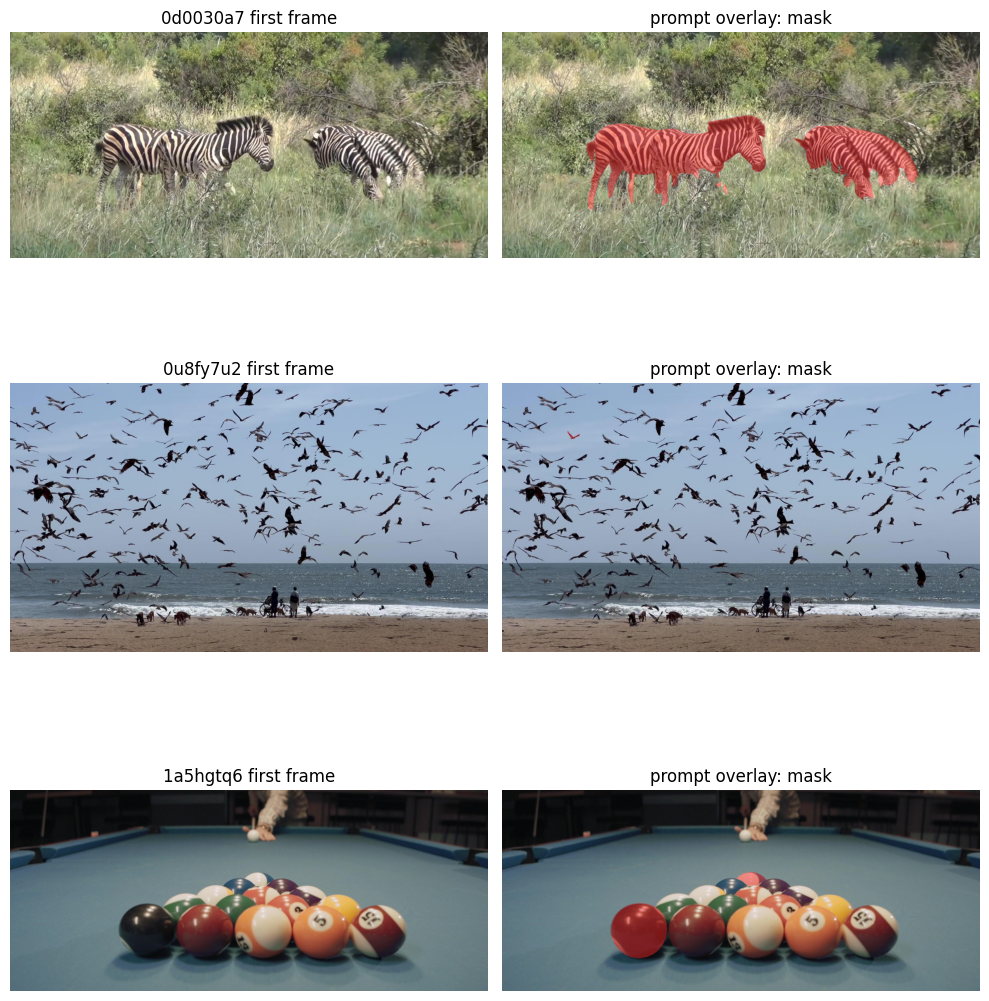

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw

def _overlay_prompt(frame_path: Path, prompt) -> Image.Image:
    """Render a lightweight overlay for mask, bbox, or point prompts."""
    image = Image.open(frame_path).convert("RGB")
    overlay = image.copy()
    draw = ImageDraw.Draw(overlay)
    prompt_path = DATA_ROOT / prompt.relative_path if prompt else None

    if prompt and prompt.prompt_type == "mask" and prompt_path and prompt_path.exists():
        mask = np.asarray(Image.open(prompt_path))
        if mask.ndim == 3:
            mask_bool = np.any(mask[..., :3] > 0, axis=-1)
        else:
            mask_bool = mask > 0
        arr = np.asarray(image).copy()
        color = np.array([255, 40, 40], dtype=np.uint8)
        arr[mask_bool] = (0.55 * arr[mask_bool] + 0.45 * color).astype(np.uint8)
        overlay = Image.fromarray(arr)
    elif prompt and prompt.prompt_type in {"bbox", "points", "mixed"} and prompt_path and prompt_path.exists():
        try:
            payload = json.loads(prompt_path.read_text(encoding="utf-8"))
            text = json.dumps(payload)[:180]
        except Exception:
            text = prompt.prompt_type
        draw.rectangle([4, 4, min(image.width - 4, 520), 42], fill=(255, 255, 255))
        draw.text((10, 14), text, fill=(255, 40, 40))
    else:
        draw.rectangle([4, 4, min(image.width - 4, 260), 34], fill=(255, 255, 255))
        draw.text((10, 12), "prompt unavailable", fill=(255, 40, 40))
    return overlay

preview_videos = [video for video in data_info.videos if video.frames][:3]
if not preview_videos:
    print("No image-frame videos available for overlay preview.")
else:
    fig, axes = plt.subplots(len(preview_videos), 2, figsize=(10, 4 * len(preview_videos)))
    if len(preview_videos) == 1:
        axes = np.array([axes])
    for row, video in enumerate(preview_videos):
        frame = video.frames[0]
        frame_path = DATA_ROOT / frame.relative_path
        prompt = video.prompts[0] if video.prompts else None
        raw = Image.open(frame_path).convert("RGB")
        overlay = _overlay_prompt(frame_path, prompt)
        axes[row, 0].imshow(raw)
        axes[row, 0].set_title(f"{video.video_id} first frame")
        axes[row, 0].axis("off")
        axes[row, 1].imshow(overlay)
        axes[row, 1].set_title(f"prompt overlay: {prompt.prompt_type if prompt else 'none'}")
        axes[row, 1].axis("off")
    plt.tight_layout()
    plt.show()

## 8. Preliminary Sanity Check

In [9]:
errors = []
warnings = []
if not data_info.videos:
    errors.append("No videos detected in DATA_ROOT")
for video in data_info.videos:
    if video.frame_count <= 0:
        warnings.append(f"{video.video_id}: frame_count is zero; may be prompt-only or unreadable video file")
    if video.source_type == "frames" and len(video.frames) != video.frame_count:
        errors.append(f"{video.video_id}: frame list length differs from frame_count")
    if video.width is None or video.height is None:
        warnings.append(f"{video.video_id}: image size is unknown")

if not format_spec.expected_masks:
    errors.append("FormatSpec has no expected masks")
if format_spec.not_verified_by_sample:
    warnings.append("format_spec is not_verified_by_sample; compare with official sample_submission.zip before final leaderboard upload")

sanity_check = {
    "passed": not errors,
    "errors": errors,
    "warnings": warnings,
    "num_videos": len(data_info.videos),
    "num_expected_submission_masks": len(format_spec.expected_masks),
    "not_verified_by_sample": format_spec.not_verified_by_sample,
    "submission_validation": "pending_until_prediction_masks_exist",
}
SANITY_CHECK_PATH.write_text(json.dumps(sanity_check, indent=2, ensure_ascii=True), encoding="utf-8")
print(json.dumps(sanity_check, indent=2, ensure_ascii=True))
print(f"sanity_check.json saved to {SANITY_CHECK_PATH}")

{
  "passed": true,
  "errors": [],
  "warnings": [
    "format_spec is not_verified_by_sample; compare with official sample_submission.zip before final leaderboard upload"
  ],
  "num_videos": 25,
  "num_expected_submission_masks": 2015,
  "not_verified_by_sample": true,
  "submission_validation": "pending_until_prediction_masks_exist"
}
sanity_check.json saved to /content/drive/MyDrive/sufe_vos_leaderboard/outputs/data_prep_20260608_065509/sanity_check.json


## 9. Run SAM2.1 Hiera Large Baseline

In [10]:
# Colab baseline run. Set RUN_SAM2_BASELINE=0 in environment to skip this long GPU step.
RUN_SAM2_BASELINE = os.environ.get("RUN_SAM2_BASELINE", "1") != "0"
SAM2_MAX_VIDEOS = os.environ.get("SAM2_MAX_VIDEOS", "0")
baseline_cmd = [
    sys.executable,
    str(PROJECT_ROOT / "scripts" / "run_baseline_sam2.py"),
    "--data-root",
    str(DATA_ROOT),
    "--output-dir",
    str(OUTPUTS_ROOT),
    "--experiment-id",
    EXPERIMENT_ID,
    "--checkpoint",
    "sam2.1_hiera_large",
    "--model-cfg",
    "configs/sam2.1/sam2.1_hiera_l.yaml",
    "--prompt-mode",
    "mask_box_points",
    "--max-videos",
    SAM2_MAX_VIDEOS,
    "--resize-long-side",
    os.environ.get("SAM2_RESIZE_LONG_SIDE", "0"),
    "--skip-existing",
    "--save-overlays",
    "sample",
    "--make-submission",
]
if Path(SAMPLE_SUBMISSION_ZIP).exists():
    baseline_cmd.extend(["--sample-submission", SAMPLE_SUBMISSION_ZIP])

print(" ".join(baseline_cmd))
if RUN_SAM2_BASELINE:
    subprocess.check_call(baseline_cmd, cwd=str(PROJECT_ROOT))
else:
    print("RUN_SAM2_BASELINE=0; command was printed but not executed.")

if RUN_SAM2_BASELINE and os.environ.get("SUFE_PUBLISH_REVIEW", "1").strip().lower() not in {"0", "false", "no"}:
    publish_dir = PUBLISH_ROOT / EXPERIMENT_ID
    publish_cmd = [
        sys.executable, str(PROJECT_ROOT / "scripts" / "publish_run_for_codex.py"),
        "--exp-dir", str(OUTPUT_DIR),
        "--publish-dir", str(publish_dir),
        "--data-root", str(DATA_ROOT),
        "--archive-dir", str(ARCHIVE_ROOT),
        "--replace",
    ]
    if os.environ.get("SUFE_MAKE_FULL_ARCHIVE", "0").strip().lower() in {"1", "true", "yes"}:
        publish_cmd.append("--make-full-archive")
    subprocess.check_call(publish_cmd, cwd=str(PROJECT_ROOT))
    print("Codex review bundle:", publish_dir)


/usr/bin/python3 /content/drive/MyDrive/sufe_vos_leaderboard/scripts/run_baseline_sam2.py --data-root /content/drive/MyDrive/sufe_vos_leaderboard/data/video_dataset --output-dir /content/drive/MyDrive/sufe_vos_leaderboard/outputs --experiment-id data_prep_20260608_065509 --checkpoint sam2.1_hiera_large --model-cfg configs/sam2.1/sam2.1_hiera_l.yaml --prompt-mode mask_box_points --max-videos 0 --resize-long-side 0 --skip-existing --make-submission
